# Практика: Наивный Байес с нуля и сравнение со `scikit-learn`

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и изучите датасет для задачи классификации;
2. подготовите данные для обучения;
3. реализуете **Гауссовский Наивный Байес с нуля**:
   - оценку априорных вероятностей классов,
   - оценку параметров (среднее и дисперсия) по каждому признаку,
   - вычисление правдоподобия (likelihood),
   - классификацию по правилу Байеса;
4. обучите свою модель;
5. сравните её качество и параметры с реализацией из `scikit-learn`;
6. проверите, что происходит при нарушении допущения о независимости признаков.

## Важно
- Сначала дописывайте пропуски в **своей** реализации.
- Только после этого переходите к сравнению со `scikit-learn`.
- Не удаляйте проверки и комментарии: они помогают вам понять ход решения.

## Датасет
Мы используем `Iris` из `sklearn.datasets`:
- задача **многоклассовой классификации** (3 класса);
- признаки числовые, непрерывные;
- датасет хорошо подходит для изучения Гауссовского Наивного Байеса.

## Что сдавать
1. Заполненный ноутбук.
2. Краткие выводы в конце:
   - насколько близки метрики вашей модели и `scikit-learn`;
   - в чём главное допущение Наивного Байеса и когда оно нарушается;
   - когда Наивный Байес предпочтительнее логистической регрессии.

## Коротко о теории

### 1. Теорема Байеса
Для классификации нам нужно найти наиболее вероятный класс \(c\) при данных признаках \(x\):

$$
P(c \mid x) = \frac{P(x \mid c) \cdot P(c)}{P(x)}
$$

Так как \(P(x)\) одинаково для всех классов, достаточно максимизировать числитель:

$$
\hat{c} = \arg\max_{c} \; P(x \mid c) \cdot P(c)
$$

### 2. Наивное допущение о независимости
«Наивным» Байес называется потому, что предполагает условную **независимость** признаков:

$$
P(x \mid c) = \prod_{j=1}^{d} P(x_j \mid c)
$$

Это сильное допущение, которое редко выполняется на практике, но модель всё равно часто работает хорошо.

### 3. Гауссовское допущение
Для непрерывных признаков предполагаем, что каждый признак имеет нормальное распределение внутри класса:

$$
P(x_j \mid c) = \frac{1}{\sqrt{2\pi\sigma_{cj}^2}} \exp\!\left(-\frac{(x_j - \mu_{cj})^2}{2\sigma_{cj}^2}\right)
$$

### 4. Логарифм для численной стабильности
Произведение многих вероятностей быстро стремится к нулю. На практике считаем **логарифм**:

$$
\log P(c \mid x) \propto \log P(c) + \sum_{j=1}^{d} \log P(x_j \mid c)
$$

### 5. Что будем сравнивать
После своей реализации вы сравните результат с `sklearn.naive_bayes.GaussianNB`:
- accuracy,
- precision (macro),
- recall (macro),
- f1 (macro).

### 6. Априорные вероятности
Оцениваются по частоте встречаемости каждого класса в обучающей выборке:

$$
P(c) = \frac{n_c}{n}
$$

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
import seaborn as sns

In [20]:
data = load_iris()
data_cancer = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X_cancer = pd.DataFrame(data_cancer.data, columns=data_cancer.feature_names)
y_cancer = pd.Series(data_cancer.target, name="target")

print("Размер X:", X.shape)
print("Классы:", data.target_names)
display(X.head())
display(y.value_counts().rename(index=dict(enumerate(data.target_names))))

Размер X: (150, 4)
Классы: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


target
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Пропуски по признакам:


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


Базовая статистика:


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


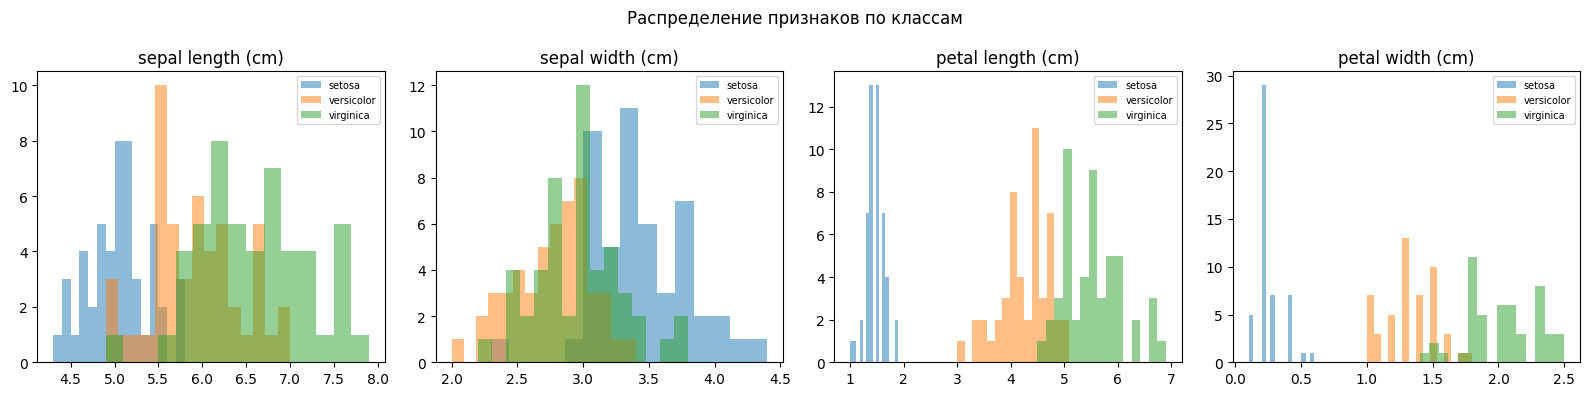

In [21]:
print("Пропуски по признакам:")
display(X.isna().sum())

print("\nБазовая статистика:")
display(X.describe().T)

# Визуализируем распределение одного признака по классам
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(X.columns):
    for cls in range(3):
        axes[i].hist(X[col][y == cls], alpha=0.5, label=data.target_names[cls], bins=15)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)
plt.suptitle("Распределение признаков по классам")
plt.tight_layout()
plt.show()

## Шаг 1. Разделение данных

Ниже нужно:
1. разбить выборку на train и test;
2. получить `X_train`, `X_test`, `y_train`, `y_test`.

Подсказка:
- используйте `train_test_split(..., test_size=0.2, random_state=42, stratify=y)`.
- **Стандартизация здесь не нужна** — Наивный Байес сам оценивает параметры распределения по каждому признаку.

In [22]:
# YOUR CODE HERE
# Разбейте данные на train/test

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.2)
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(X_cancer, y_cancer, stratify=y_cancer, random_state=42, test_size=0.2)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Распределение классов в train:", pd.Series(y_train).value_counts().to_dict())
print("Train shape:", X_train_cancer.shape)
print("Test shape:", X_test_cancer.shape)
print("Распределение классов в train:", pd.Series(y_train_cancer).value_counts().to_dict())


Train shape: (120, 4)
Test shape: (30, 4)
Распределение классов в train: {0: 40, 2: 40, 1: 40}
Train shape: (455, 30)
Test shape: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Оцениваем априорные вероятности классов

Напишите функцию `compute_priors(y)`, которая возвращает словарь `{класс: P(класс)}`.

Проверка:
- сумма всех вероятностей должна быть равна `1.0`.

In [23]:
def compute_priors(y):
    """
    Вычисляет априорные вероятности каждого класса.
    Возвращает словарь {класс: вероятность}.
    """
    # YOUR CODE HERE
    unique_classes = np.unique(y)
    n = len(y)
    priors = np.zeros(len(unique_classes))
    for i, c in enumerate(unique_classes):
        priors[i] = np.sum(y == c) / n
    return priors

priors = compute_priors(y_train.values)
print("Априорные вероятности:", priors)
print("Сумма:", sum(priors))

priors_cancer = compute_priors(y_train_cancer.values)
print("Априорные вероятности:", priors_cancer)
print("Сумма:", sum(priors_cancer))

Априорные вероятности: [0.3333 0.3333 0.3333]
Сумма: 1.0
Априорные вероятности: [0.3736 0.6264]
Сумма: 1.0


## Шаг 3. Оцениваем параметры распределений по каждому классу

Для Гауссовского Наивного Байеса нужно по каждому классу и каждому признаку оценить:
- **среднее** `mu[c, j]` — среднее значение признака \(j\) в классе \(c\),
- **дисперсию** `var[c, j]` — дисперсию признака \(j\) в классе \(c\).

Напишите функцию `fit_gaussian_params(X, y)`, которая возвращает два массива: `means` и `variances` формы `(n_classes, n_features)`.

Подсказка:
- используйте `np.var(...)` — это **несмещённую** дисперсию лучше считать с `ddof=0` (по умолчанию).

In [24]:
def fit_gaussian_params(X, y):
    """
    Оценивает mu и var для каждого (класс, признак).
    X: np.array (n_samples, n_features)
    y: np.array (n_samples,)
    Возвращает: means (n_classes, n_features), variances (n_classes, n_features)
    """
    classes = np.unique(y)
    n_classes = len(classes)
    n_features = X.shape[1]

    means = np.zeros((n_classes, n_features))
    variances = np.zeros((n_classes, n_features))

    for i, c in enumerate(classes):
        # YOUR CODE HERE
        # выберите строки X, где y == c
        # посчитайте среднее и дисперсию по каждому признаку
        means[i] = X[y == c].mean(axis=0)
        variances[i] = X[y==c].var(axis=0, ddof=0)

    return means, variances


X_train_np = X_train.values
y_train_np = y_train.values
X_train_np_cancer = X_train_cancer.values
y_train_np_cancer = y_train_cancer.values

means, variances = fit_gaussian_params(X_train_np, y_train_np)
print("means shape:", means.shape)
print("\nМатрица средних для ирисов (класс x признак):")
display(pd.DataFrame(means, columns=data.feature_names, index=data.target_names).round(3))
print("\nМатрица дисперсий для ирисов (класс x признак):")
display(pd.DataFrame(variances, columns=data.feature_names, index=data.target_names).round(4))

means shape: (3, 4)

Матрица средних для ирисов (класс x признак):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.985,3.415,1.477,0.255
versicolor,5.930,2.750,4.252,1.320
virginica,6.610,2.980,5.580,2.040



Матрица дисперсий для ирисов (класс x признак):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,0.0928,0.1553,0.0252,0.0130
versicolor,0.2216,0.0930,0.1915,0.0341
virginica,0.4574,0.1221,0.3236,0.0704


## Шаг 4. Вычисляем log-likelihood

Напишите функцию `gaussian_log_likelihood(x, mean, var)`, которая возвращает логарифм плотности нормального распределения:

$$
\log P(x_j \mid c) = -\frac{1}{2}\log(2\pi\sigma^2) - \frac{(x_j - \mu)^2}{2\sigma^2}
$$

Подсказка:
- `var` может быть очень маленьким — добавьте небольшую константу `eps=1e-9` к дисперсии во избежание деления на ноль.

In [25]:
def gaussian_log_likelihood(x, mean, var, eps=1e-9):
    """
    Считает log P(x | mu, sigma^2) по нормальному распределению.
    x, mean, var: np.array одинаковой формы (n_features,)
    Возвращает: сумму log-вероятностей по всем признакам (скаляр).
    """
    # YOUR CODE HERE

    log_likelihood = np.sum(-((1/2)*(np.log(2*np.pi*(var+eps)))+(x-mean)**2/(2*(var+eps)))) # задание A
    return log_likelihood


# Проверка: для одного объекта, одного класса
test_x = X_train_np[0]
ll = gaussian_log_likelihood(test_x, means[0], variances[0])
print("Log-likelihood для первого объекта (класс 0):", ll)

Log-likelihood для первого объекта (класс 0): -0.47769884377699867


## Шаг 5. Собираем классификатор в класс

Допишите методы:
- `fit` — оценить прайоры, средние и дисперсии;
- `predict_log_proba` — вычислить логарифм апостериорной вероятности для каждого класса;
- `predict` — вернуть класс с наибольшей апостериорной вероятностью.

Требования:
- использовать логарифмы для численной стабильности;
- метод должен работать на `numpy`-массивах.

In [26]:
class MyGaussianNB:
    def __init__(self):
        self.classes_ = None
        self.log_priors_ = None  # логарифмы априорных вероятностей
        self.means_ = None       # (n_classes, n_features)
        self.variances_ = None   # (n_classes, n_features)

    def fit(self, X, y):
        """
        Оцениваем все параметры по обучающей выборке.
        """
        # YOUR CODE HERE
        # 1) сохраните уникальные классы в self.classes_
        # 2) вычислите log-прайоры
        # 3) вычислите средние и дисперсии через fit_gaussian_params
        self.classes_= np.unique(y)
        self.log_priors_ = np.log(compute_priors(y))
        self.means_, self.variances_ = fit_gaussian_params(X, y)
        return self

    def predict_log_proba(self, X):
        """
        Для каждого объекта и каждого класса вычисляет
        log P(c) + sum_j log P(x_j | c).
        Возвращает массив (n_samples, n_classes).
        """
        # YOUR CODE HERE
        # для каждого класса: log_prior + gaussian_log_likelihood
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        log_proba = np.zeros((n_samples, n_classes))
        for i, c in enumerate(self.classes_):
            c_means = self.means_[i]
            c_variances = self.variances_[i]
            for j in range(n_samples):
                x_j = X[j]
                log_likelyhood = gaussian_log_likelihood(x_j, c_means, c_variances)
                log_proba[j][i] = self.log_priors_[i] + log_likelyhood
        return log_proba

    def predict_proba(self, X):
        log_proba = self.predict_log_proba(X)
        preds = np.exp(log_proba) / np.sum(np.exp(log_proba), axis=1, keepdims=True)
        return preds

    def predict(self, X):
        """
        Возвращает предсказанный класс для каждого объекта.
        """
        # YOUR CODE HERE
        # argmax по log_proba
        log_proba = self.predict_log_proba(X)
        preds = np.argmax(log_proba, axis=1)
        return preds

## Шаг 6. Обучаем свою модель

Обучите `MyGaussianNB` и убедитесь, что:
- модель обучилась без ошибок;
- параметры имеют ожидаемую форму.

In [27]:
my_model = MyGaussianNB()
my_model_cancer = MyGaussianNB()

# YOUR CODE HERE
# обучите модель на X_train_np и y_train_np
my_model.fit(X_train_np, y_train_np)
my_model_cancer.fit(X_train_np_cancer, y_train_np_cancer)

print("Классы:", my_model.classes_)
print("Log-прайоры:", my_model.log_priors_)
print("Форма means_:", my_model.means_.shape)
print("Классы:", my_model_cancer.classes_)
print("Log-прайоры:", my_model_cancer.log_priors_)
print("Форма means_:", my_model_cancer.means_.shape)

Классы: [0 1 2]
Log-прайоры: [-1.0986 -1.0986 -1.0986]
Форма means_: (3, 4)
Классы: [0 1]
Log-прайоры: [-0.9845 -0.4678]
Форма means_: (2, 30)


## Шаг 7. Оценка качества своей модели

Заполните код ниже и посчитайте метрики на тестовой выборке:
- accuracy,
- precision (macro),
- recall (macro),
- f1 (macro).

In [28]:
X_test_np = X_test.values
y_test_np = y_test.values

# YOUR CODE HERE
my_pred_test = my_model.predict(X_test_np)
my_pred_proba = my_model.predict_proba(X_test_np)

my_metrics = {
    "accuracy": accuracy_score(y_test_np, my_pred_test),
    "precision_macro": precision_score(y_test_np, my_pred_test, average = 'macro'),
    "recall_macro": recall_score(y_test_np, my_pred_test, average = 'macro'),
    "f1_macro": f1_score(y_test_np, my_pred_test, average = 'macro'),
}

pd.Series(my_metrics).round(4)

accuracy           0.9667
precision_macro    0.9697
recall_macro       0.9667
f1_macro           0.9666
dtype: float64

In [29]:
np.set_printoptions(precision=4, suppress=True, floatmode='fixed', edgeitems=2, threshold=2)
print(my_pred_proba)
np.set_printoptions(suppress=False) # Задание C

[[1.0000 0.0000 0.0000]
 [0.0000 0.0877 0.9123]
 ...
 [0.0000 0.0010 0.9990]
 [1.0000 0.0000 0.0000]]


In [30]:
X_test_np_cancer = X_test_cancer.values
y_test_np_cancer = y_test_cancer.values

# YOUR CODE HERE
my_pred_test_cancer = my_model_cancer.predict(X_test_np_cancer)
my_pred_proba_cancer = my_model_cancer.predict_proba(X_test_np_cancer)

my_metrics_cancer = {
    "accuracy": accuracy_score(y_test_np_cancer, my_pred_test_cancer),
    "precision_macro": precision_score(y_test_np_cancer, my_pred_test_cancer, average = 'macro'),
    "recall_macro": recall_score(y_test_np_cancer, my_pred_test_cancer, average = 'macro'),
    "f1_macro": f1_score(y_test_np_cancer, my_pred_test_cancer, average = 'macro'),
}

pd.Series(my_metrics_cancer).round(4)

accuracy           0.9298
precision_macro    0.9246
recall_macro       0.9246
f1_macro           0.9246
dtype: float64

## Шаг 8. Confusion matrix

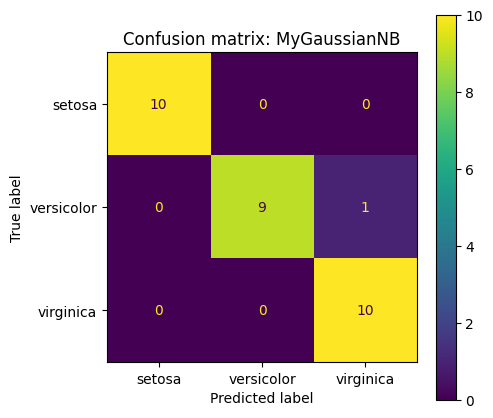

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [31]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_np, my_pred_test,
    display_labels=data.target_names,
    ax=ax
)
plt.title("Confusion matrix: MyGaussianNB")
plt.show()

print(classification_report(y_test_np, my_pred_test, target_names=data.target_names))

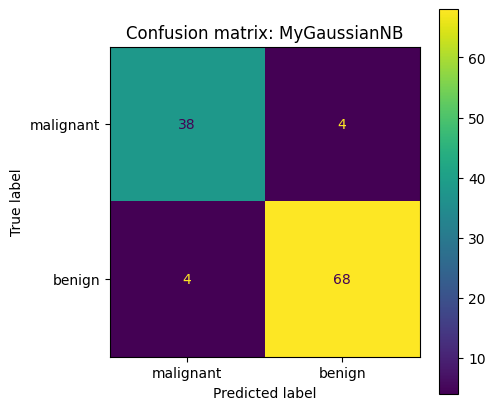

              precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        42
      benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [32]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_np_cancer, my_pred_test_cancer,
    display_labels=data_cancer.target_names,
    ax=ax
)
plt.title("Confusion matrix: MyGaussianNB")
plt.show()

print(classification_report(y_test_np_cancer, my_pred_test_cancer, target_names=data_cancer.target_names))

## Покажем матрица корреляций признаков датасета breast_cancer:

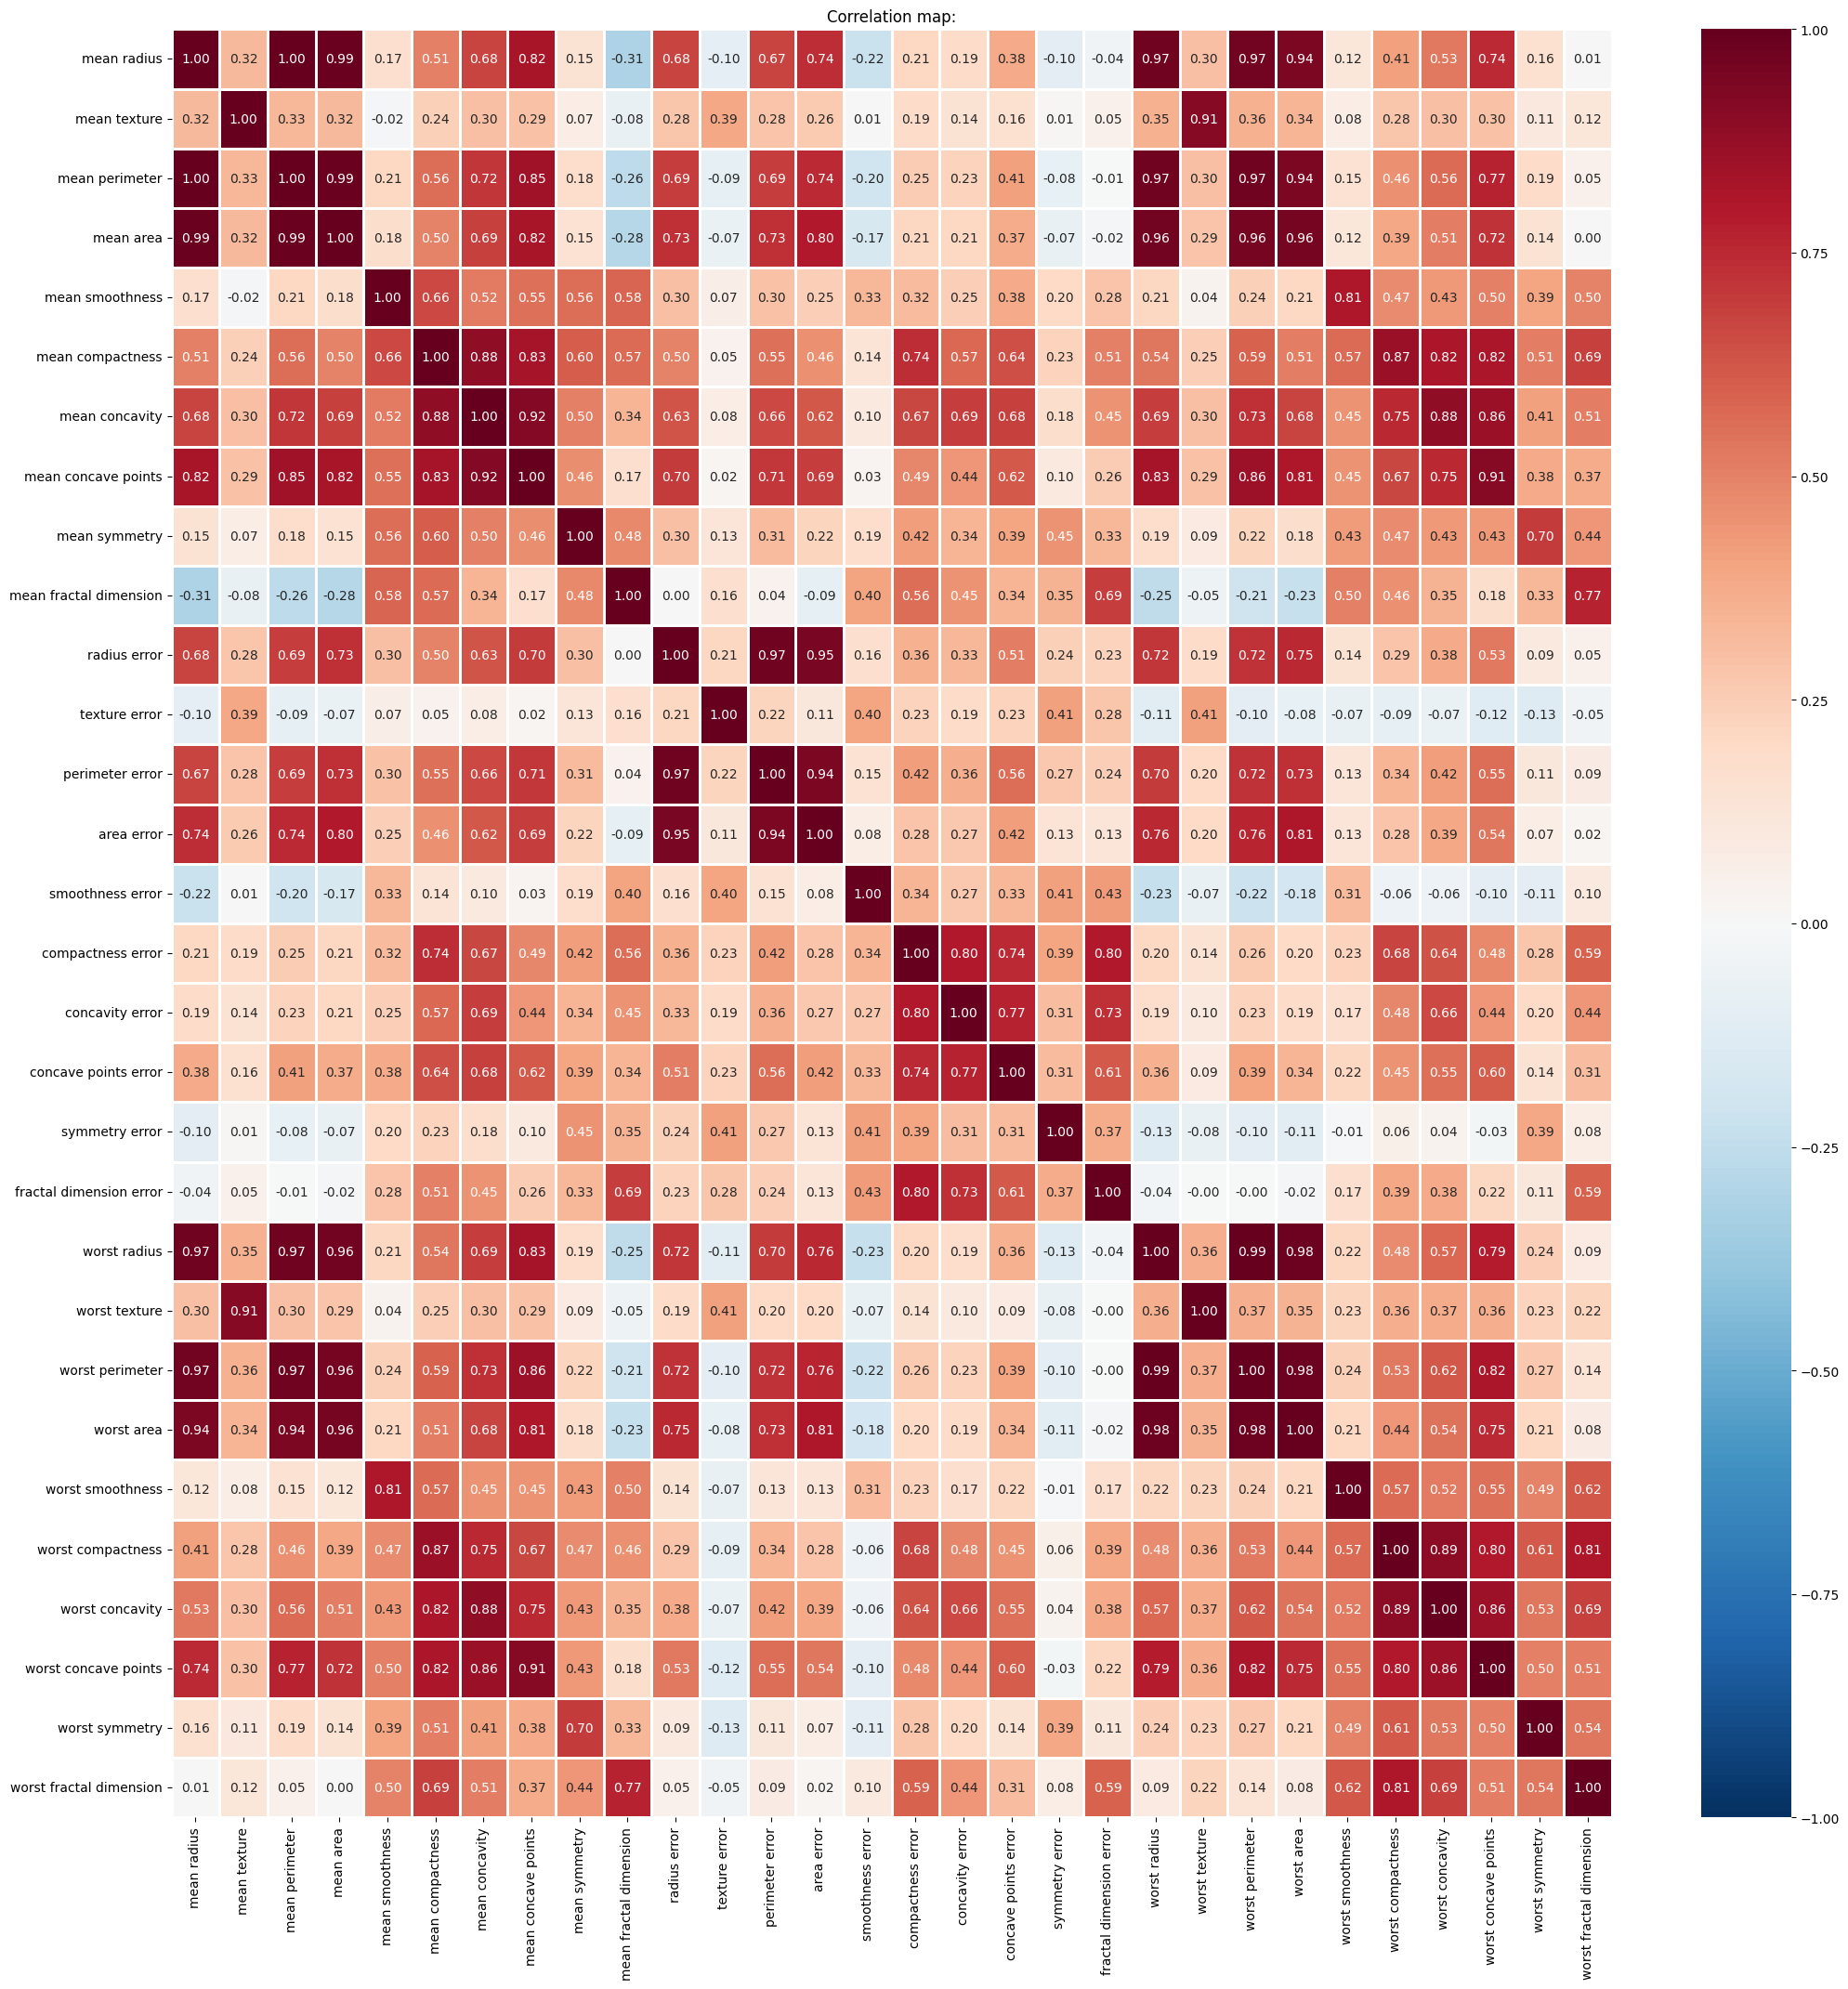

In [33]:
plt.figure(figsize=(25, 25))
corr_matrix = X_cancer.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(
    corr_matrix, 
    annot=True,        
    cmap='RdBu_r',   
    fmt='.2f',
    center=0,       
    linewidths=1,      
    vmin=-1, vmax=1    
)
plt.title('Correlation map:')
plt.show()

Вывод: признаки сильно скоррелированны, поэтому датасет требует дополнительных EDA и feature-engineering-а, чтобы получить хорошо работающую модель с помощью Naive Bayes.

## Шаг 9. Сравнение с `scikit-learn`

Теперь обучите библиотечный `GaussianNB` и сравните его с вашей реализацией.

Рекомендации:
- используйте `GaussianNB()` без дополнительных параметров;
- обучайте на тех же данных `X_train_np`.

In [34]:
sk_model = GaussianNB()

# YOUR CODE HERE
# 1) обучите sk_model
# 2) получите предсказания на test
# 3) посчитайте те же метрики
sk_model.fit(X_train, y_train)
y_test_pred = sk_model.predict(X_test)

sk_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred),
    "precision_macro": precision_score(y_test, y_test_pred, average='macro'),
    "recall_macro": recall_score(y_test, y_test_pred, average='macro'),
    "f1_macro": f1_score(y_test, y_test_pred, average='macro')
}

pd.Series(sk_metrics).round(4)

accuracy           0.9667
precision_macro    0.9697
recall_macro       0.9667
f1_macro           0.9666
dtype: float64

## Шаг 10. Сводная таблица сравнения

Сравните:
1. свою реализацию;
2. `scikit-learn`.

Также сравните оценённые параметры (средние) между реализациями.

Подумайте:
- почему результаты совпадают или отличаются;
- есть ли разница в том, как `sklearn` обрабатывает дисперсию (подсказка: посмотрите параметр `var_smoothing`).

In [35]:
comparison = pd.DataFrame(
    [my_metrics, my_metrics_cancer, sk_metrics],
    index=["my_model", "my_model_cancer", "sklearn"]
)
display(comparison.round(4))

# Сравниваем оценённые средние
print("\nСредние MyGaussianNB:")
display(pd.DataFrame(my_model.means_, columns=data.feature_names, index=data.target_names).round(4))

print("\nСредние MyGaussianNB на датасете breast_cancer:")
display(pd.DataFrame(my_model_cancer.means_, columns=data_cancer.feature_names, index=data_cancer.target_names).round(4))

print("\nСредние sklearn GaussianNB:")
display(pd.DataFrame(sk_model.theta_, columns=data.feature_names, index=data.target_names).round(4))

,accuracy,precision_macro,recall_macro,f1_macro
my_model,0.9667,0.9697,0.9667,0.9666
my_model_cancer,0.9298,0.9246,0.9246,0.9246
sklearn,0.9667,0.9697,0.9667,0.9666



Средние MyGaussianNB:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.985,3.415,1.4775,0.255
versicolor,5.930,2.750,4.2525,1.320
virginica,6.610,2.980,5.5800,2.040



Средние MyGaussianNB на датасете breast_cancer:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
malignant,17.3812,21.5799,114.8306,966.8200,0.1030,0.1461,0.1624,0.0876,0.1936,0.0628,...,20.9671,29.2768,140.2582,1396.7712,0.1448,0.3789,0.4632,0.1828,0.3268,0.0917
benign,12.0904,17.8560,77.6751,458.6905,0.0921,0.0787,0.0455,0.0249,0.1729,0.0628,...,13.3201,23.4824,86.5636,554.2316,0.1249,0.1800,0.1652,0.0728,0.2694,0.0793



Средние sklearn GaussianNB:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.985,3.415,1.4775,0.255
versicolor,5.930,2.750,4.2525,1.320
virginica,6.610,2.980,5.5800,2.040


## Шаг 11. Проверяем допущение о независимости

Наивный Байес предполагает, что признаки **условно независимы** при данном классе.
Проверим, насколько это выполняется: вычислим корреляции между признаками внутри каждого класса.

Подумайте:
- какие пары признаков наиболее скоррелированы;
- нарушает ли это допущение о независимости;
- как это влияет на качество модели.

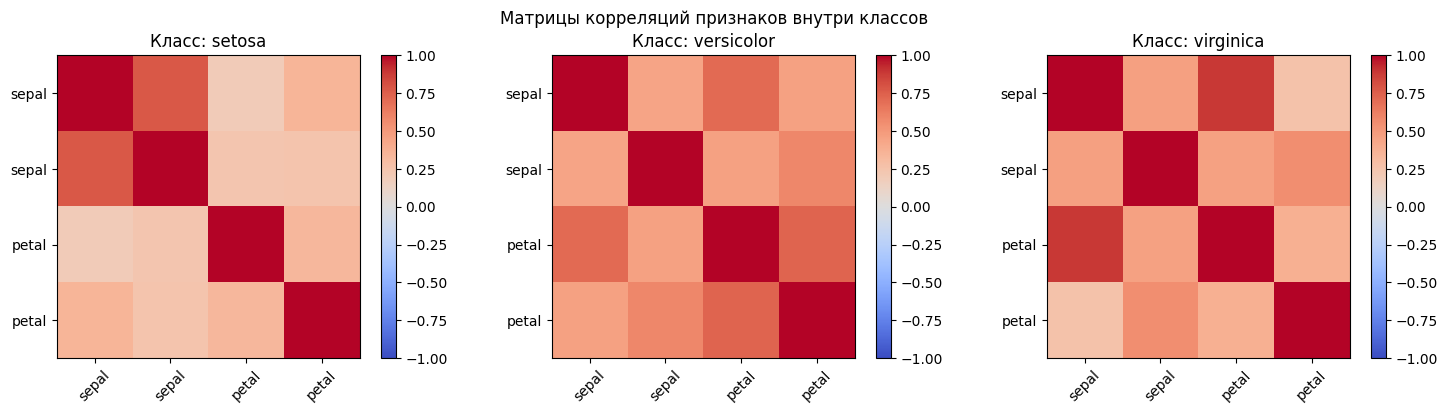

Корреляции для класса setosa:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000,0.775,0.194,0.348
sepal width (cm),0.775,1.000,0.241,0.249
petal length (cm),0.194,0.241,1.000,0.331
petal width (cm),0.348,0.249,0.331,1.000


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for cls in range(3):
    X_cls = X_train[y_train == cls]
    corr = X_cls.corr()
    im = axes[cls].imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm")
    axes[cls].set_title(f"Класс: {data.target_names[cls]}")
    axes[cls].set_xticks(range(4))
    axes[cls].set_yticks(range(4))
    axes[cls].set_xticklabels([f.split(' ')[0] for f in data.feature_names], rotation=45)
    axes[cls].set_yticklabels([f.split(' ')[0] for f in data.feature_names])
    plt.colorbar(im, ax=axes[cls])

plt.suptitle("Матрицы корреляций признаков внутри классов")
plt.tight_layout()
plt.show()

print("Корреляции для класса setosa:")
display(X_train[y_train == 0].corr().round(3))

## Финальные вопросы для ответа текстом

Ответьте кратко, но по существу.

1. В чём заключается «наивное» допущение Наивного Байеса? Почему его так называют?
2. Почему мы используем логарифм правдоподобия вместо самого правдоподобия?
3. Почему для Гауссовского Наивного Байеса стандартизация данных **не нужна**?
4. Насколько близки метрики вашей реализации к `scikit-learn`? Если есть расхождения — объясните их.
5. Посмотрите на матрицы корреляций: нарушается ли допущение о независимости признаков?
6. Когда Наивный Байес работает хорошо несмотря на нарушение допущения о независимости?
7. Сравните Наивный Байес и Логистическую регрессию: когда предпочесть один метод другому?

## Дополнительные задания

### Задание A
Добавьте параметр `var_smoothing` в `MyGaussianNB` (аналог `sklearn`): добавляйте к дисперсии небольшую долю от максимальной дисперсии по всем признакам. Посмотрите, как это влияет на метрики.

### Задание B
Попробуйте применить `MyGaussianNB` к датасету `Breast Cancer` (из семинара по логистической регрессии). Сравните качество с логистической регрессией. Объясните разницу.

### Задание C
Реализуйте `predict_proba` — метод, возвращающий нормированные вероятности (не логарифмы). Для этого:
- вычислите `log_proba`,
- вычтите максимум (для численной стабильности),
- примените `exp`,
- нормируйте на сумму.

## Выводы и доп. задания:

Выводы:
1) Наивное допущение наивного Байеса состоит в том, что мы считаем, что признаки в нашем признаковом пространстве независимы, что позволяет скоратить с алгоритмической точки зрения задачу до n^2, не сильно теряя в качестве решения (на практике установленная "истина").
2) Мы используем логарифм правдоподобия, чтобы превратить формульно произведение в сумму, параллельно избавляясь от слишком маленьких значений произведения вероятностей и, как следствия - потери данных о них (близкие к нулю значения будут 0, например). Да и вообще говоря, так просто удобней... Берём число, близкое к 1 (вероятность, нужная нам). После логарифмирования получим число, близкое к 0 (см. функцию логарифма), остальные числа от 0 до 1 - отрицательные. Берём с минусом и минимизируем - крутяк же. 
3) А зачем? он сразу работает с вероятностями от 0 до 1 и считает, что данные распределены нормально. Мы можем, конечно, стандартизировать, но значение поменяются не сильно, следовательно в этом просто нет смысла (особенно на датасете Iris, где все значения очень близки).
4) Расхождений нет. Метрики идентичны. Причины - маленький датасет (расхождения, скорее всего, говорили бы о неправильном обучении модели мною), гениальность моя и наших прекрасных лекторов, что так доходчиво объяснили принцип работы этого алгоритма обучения.
5) Нарушают (так, например, sepal длина и ширина коррелируют почти на 75%).
6) Когда обучающая выборка маленькая, объектов в данных меньше, чем признаков, когда датасет содержит много категориальных признаков (в идеале - 2 и более пункта должны выполняться).
7) Наивный Байес - когда из п.6 выполнено хотя бы 2 пункта или нужно быстро обучить хоть что-то. Логистическая регрессия - признаки числовые, не требует независимости признаков, не лень стандартизировать данные.

Доп. задания:
- Задание A выполнено в шаге 4;
- Задание B выполнено по всему notebook. Результат каждой метрики около 93%. Результат логистической регрессии - 98% (по confusion matrix видим, что по каждому классу модель, обученная наивным Байесом, сделала на 3 ошибки больше (1 у логистической регрессии, 4 у наивного Байеса)). Причина ошибки - допущение наивного Байеса о независимости признаков (как мы помним из предыдущий домашки, в этом датасете признаки сильно коррелируются).
- Задание C выполнено в шаге 6 (метод класса), вывод результата выполнен в шаге 7;

## Что должно получиться в итоге

После заполнения ноутбука у вас должен быть полный pipeline:

- загрузка данных;
- train/test split;
- оценка параметров Гауссовского Наивного Байеса с нуля;
- классификация по правилу Байеса;
- метрики качества;
- сравнение со `scikit-learn`;
- анализ допущения о независимости;
- выводы.

Не сдавайте ноутбук без текстовых выводов.